# Taller 2: operaciones de transformación del histograma

### Sebastián Palma

### David Tobón Molina

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Filtros lineales suavizantes


## 2. Filtros lineales separables

## 3. Filtros no lineales

Los filtros lineales calculan siempre un promedio ponderado de todos los píxeles de un cierto vecindario. Los filtros no lineales permiten, entre otras, hacer una selección dentro de este vecindario y utilizar únicamente un subconjunto de píxeles que presentan propiedades comunes.

### 3.2 Cargue la imagen morpho en escala de grises y visualícela.

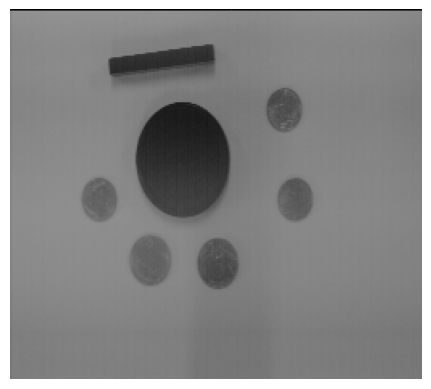

In [21]:
morpho_img = cv2.imread('images/MORPHO.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(morpho_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.3 Perturbe (ensucie) la imagen con 25% de ruido “sal y pimienta”. En la imagen ya existen pixeles aberrantes (con intensidades extremas). Esta operación es hecha para amplificar el fenómeno y facilitar la respuesta a la pregunta 9. Nota: El ruido “pimienta y sal” está constituido de picos claros y oscuros (cuyos valores se deben definir en el módulo) con distribución espacial aleatoria. 25 % de pixeles perturbados por este ruido son suficientes para que la imagen morpho.png sea bastante degradada.

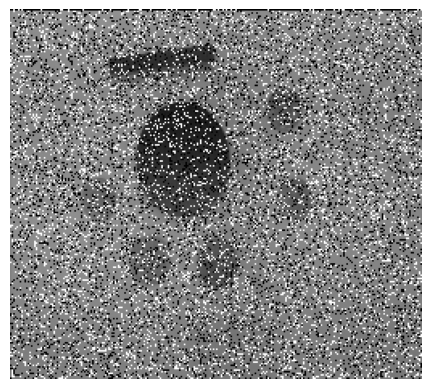

In [22]:
from skimage.util import random_noise

noised_image = random_noise(morpho_img, mode='s&p', amount=0.25)
plt.imshow(noised_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.show()

### 3.4 Aplique un filtro promedio 3x3 sobre la imagen con ruido. Visualmente, ¿cómo es el resultado y a qué se debe?

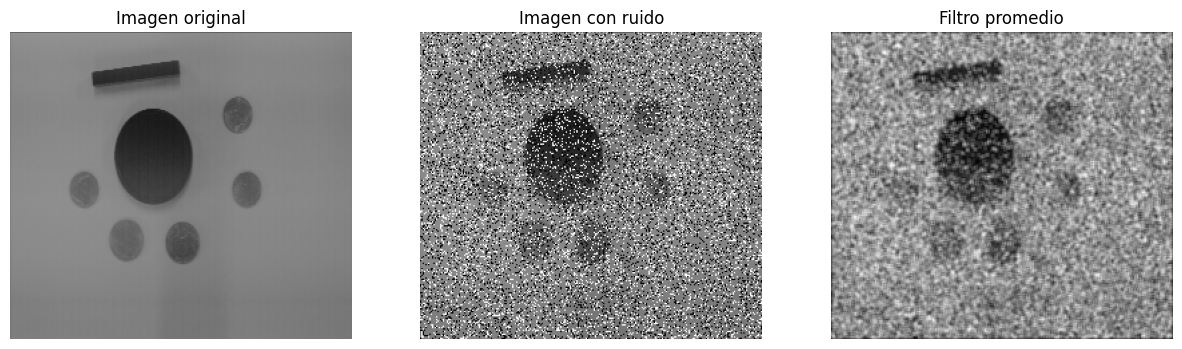

In [23]:
from scipy.ndimage import convolve

kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]])

avg_filter_result = convolve(noised_image, kernel, mode='constant', cval=0)

plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.imshow(morpho_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('Imagen original')

plt.subplot(1,3,2)
plt.imshow(noised_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Imagen con ruido')

plt.subplot(1,3,3)
plt.imshow(avg_filter_result, cmap='gray')
plt.axis('off')
plt.title('Filtro promedio')

plt.show()


El ruido de la imagen se suaviza pero sigue siendo ruido y no se recuperan los detalles de la imagen original, lo que eran los puntos blancos y negros se vuelven manchas de grises claros y oscuros. Esto se debe a que los filtros promedio toman en cuenta todos los píxeles bajo su ventana. En este caso, se toman en cuenta los 9 píxeles de la imagen que se encuentran en la ventana de 3x3. Al tomar en cuenta todos los píxeles y hacer un promedio, los valores de los píxeles ruido afectan en gran parte al resultado, pues estos hacen que el resultado del promedio aritmético de las intensidades de los píxeles se desplace significativamente. Por ejemplo, un solo píxel de "sal" (255) en una vecindad de píxeles oscuros elevará el promedio de toda la celda, creando una mancha gris clara en lugar de eliminar el punto blanco.

### 3.5 Aplique un filtro sigma 3x3 calculando el valor medio a partir pixel central sobre la imagen con ruido. Visualmente, ¿cómo es el resultado comparado con el filtro promedio lineal? Consultando la definición del Sigma explique este resultado. En el caso del ruido “sal y pimienta”, después de aplicar el filtro Sigma, quedan varios puntos aberrantes. ¿A qué se debe esto?

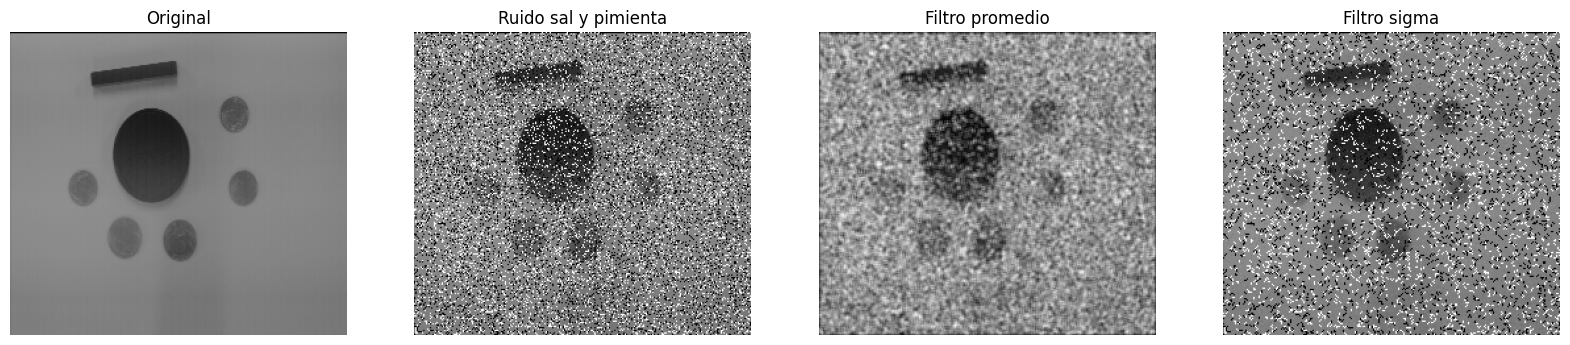

In [24]:
import numpy as np
from scipy.ndimage import generic_filter


def sigma_filter(values, median=False):
    
    mean = values[int((values.size)//2)]
    if median:
      mean = np.median(values)

    std = np.std(values)
    filtered_values = values[(values > mean - std) & (values < mean + std)]
    return np.mean(values) if filtered_values.size<=1 else np.mean(filtered_values)


sigma_filter_result = generic_filter(noised_image, sigma_filter, size=(3,3))

plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.imshow(morpho_img, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(noised_image, cmap='gray', vmin=0, vmax=1)
plt.title('Ruido sal y pimienta')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(avg_filter_result, cmap='gray')
plt.title('Filtro promedio')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(sigma_filter_result, cmap='gray', vmin=0, vmax=1)
plt.title('Filtro sigma')
plt.axis('off')

plt.show()

Tras aplicar el filtro sigma el ruido aún persiste, pero parece que la imagen conserva su nitidez en lugar de ponerse borrosa como sucede con el filtro promedio. Esto se debe a que el filtro sigma es un filtro selectivo que se utiliza para preserbar los bordes de la imagen. El filtro sigma calcula el promedio solamente de los píxeles vecinos que caen dentro de un rango estadístico ($\text{media} \pm \sigma$). Asume que los píxeles que están fuera de ese rango pertenecen a otra distribución, por ejemplo, un borde u otro objeto, y los ignora, sin aplicarles el filtrado, dejándolos intactos. De este modo, el filtro interpreta los píxeles de sal y pimienta como parte de otra distribución y los ignora, creyendo que deben de ser preservados.

### 3.6 Aplique un filtro mediano 3x3 a la imagen con ruido. Visualmente, ¿cómo es el resultado comparado con los dos filtros anteriores? ¿A qué se debe este resultado? Evalúe los otros filtros que ofrece el módulo filters.rank de scikit-image: majority, maximum, minumum, modal, geometric_mean. Explique su comportamiento.

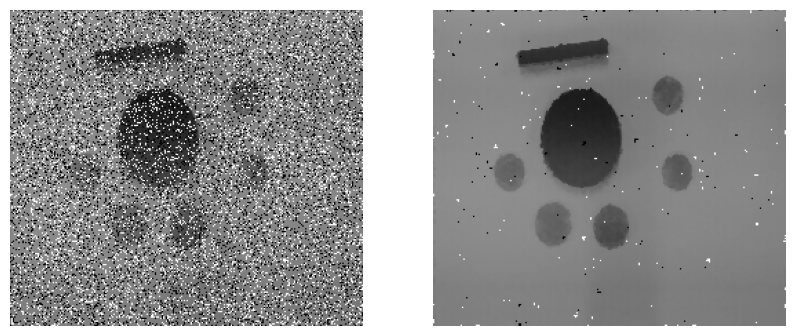

In [25]:
from skimage.filters.rank import median, majority, maximum, minimum, modal, geometric_mean
from skimage.util import img_as_ubyte

noised_image_ubyte = img_as_ubyte(noised_image)
median_filter_result = median(noised_image_ubyte, footprint=np.ones((3, 3)))


plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.imshow(noised_image, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(median_filter_result, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


Comparado con los filtros anteriores, el resultado presenta un mejor filtrado del ruido sal y pimienta, aunque de todos modos cierta cantidad de ruido persiste, pero a pesar de este, se puede observar un imagen mucho más cercana a la original. Esta exitosa eliminación de la mayoría del ruido se logra ya que el filtro de Mediana es un filtro no lineal que selecciona el valor mediano de los píxeles en el vecindario, lo que lo hace muy efectivo para eliminar el ruido sal y pimienta, pues usualmente la mediana de la ventana de píxeles será un valor intermedio, y se ignoraran los valores extremos (ruido).

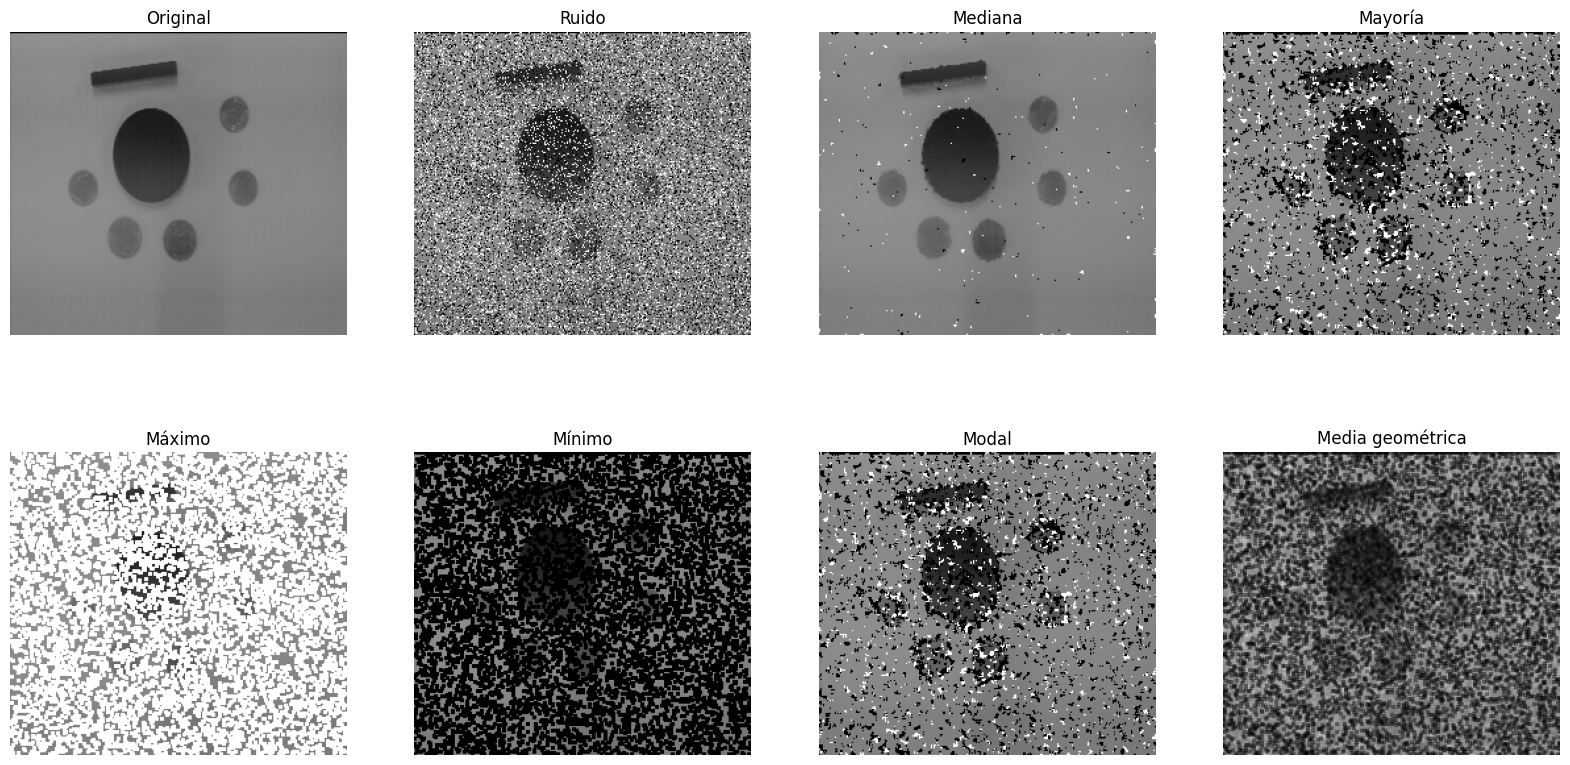

In [26]:
# evaluación con otros filtros

majority_filter_result = majority(noised_image_ubyte, footprint=np.ones((3,3)))
maximum_filter_result = maximum(noised_image_ubyte, footprint=np.ones((3,3)))
minimum_filter_result = minimum(noised_image_ubyte, footprint=np.ones((3,3)))
modal_filter_result = modal(noised_image_ubyte, footprint=np.ones((3,3)))
geometric_mean_filter_result = geometric_mean(noised_image_ubyte, footprint=np.ones((3,3)))

plt.figure(figsize=(20,10))

plt.subplot(2, 4, 1)
plt.imshow(morpho_img, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(noised_image, cmap='gray', vmin=0, vmax=1)
plt.title('Ruido')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(median_filter_result, cmap='gray', vmin=0, vmax=255)
plt.title('Mediana')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(majority_filter_result, cmap='gray', vmin=0, vmax=255)
plt.title('Mayoría')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(maximum_filter_result, cmap='gray', vmin=0, vmax=255)
plt.title('Máximo')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(minimum_filter_result, cmap='gray', vmin=0, vmax=255)
plt.title('Mínimo')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(modal_filter_result, cmap='gray', vmin=0, vmax=255)
plt.title('Modal')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(geometric_mean_filter_result, cmap='gray', vmin=0, vmax=255)
plt.title('Media geométrica')
plt.axis('off')

plt.show()

## 4. Ejercicio de síntesis taller 5